In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/raw/data.csv")

# Preview
df.head()

,x_Timestamp,t_kWh,z_Avg Voltage (Volt),z_Avg Current (Amp),y_Freq (Hz),meter
0,2021-01-02 00:00:00,0.002,253.36,0.25,50.09,BR02
1,2021-01-02 00:03:00,0.002,253.87,0.25,50.11,BR02
2,2021-01-02 00:06:00,0.020,253.25,1.67,50.14,BR02
3,2021-01-02 00:09:00,0.045,252.20,3.52,50.12,BR02
4,2021-01-02 00:12:00,0.044,252.28,3.53,50.07,BR02


In [22]:
df.shape


(3300480, 6)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3300480 entries, 0 to 3933599
Data columns (total 6 columns):
 #   Column                Dtype         
---  ------                -----         
 0   x_Timestamp           datetime64[ns]
 1   t_kWh                 float64       
 2   z_Avg Voltage (Volt)  float64       
 3   z_Avg Current (Amp)   float64       
 4   y_Freq (Hz)           float64       
 5   meter                 object        
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 176.3+ MB


In [24]:
df.columns

Index(['x_Timestamp', 't_kWh', 'z_Avg Voltage (Volt)', 'z_Avg Current (Amp)',
       'y_Freq (Hz)', 'meter'],
      dtype='object')

In [25]:
df['x_Timestamp'] = pd.to_datetime(df['x_Timestamp'])

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3300480 entries, 0 to 3933599
Data columns (total 6 columns):
 #   Column                Dtype         
---  ------                -----         
 0   x_Timestamp           datetime64[ns]
 1   t_kWh                 float64       
 2   z_Avg Voltage (Volt)  float64       
 3   z_Avg Current (Amp)   float64       
 4   y_Freq (Hz)           float64       
 5   meter                 object        
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 176.3+ MB


In [27]:
(df == 0).sum()

x_Timestamp                  0
t_kWh                   342264
z_Avg Voltage (Volt)    249596
z_Avg Current (Amp)     299500
y_Freq (Hz)             249597
meter                        0
dtype: int64

In [28]:
df.groupby('meter').apply(lambda x: (x == 0).sum())

,x_Timestamp,t_kWh,z_Avg Voltage (Volt),z_Avg Current (Amp),y_Freq (Hz),meter
meter,,,,,,
BR02,0,1678,570,820,570,0
BR04,0,5569,5162,5422,5162,0
BR05,0,5013,1157,1157,1157,0
BR06,0,5066,5069,5069,5069,0
BR08,0,848,595,596,595,0
BR09,0,1215,492,1173,492,0
BR11,0,4840,4703,4734,4703,0
BR12,0,665,634,639,634,0
BR15,0,4871,4520,4529,4520,0


In [29]:
zero_counts = df.groupby('meter').apply(lambda x: (x == 0).sum())

total_counts = df.groupby('meter').size()

zero_percentage = zero_counts.div(total_counts, axis=0) * 100

zero_percentage

,x_Timestamp,t_kWh,z_Avg Voltage (Volt),z_Avg Current (Amp),y_Freq (Hz),meter
meter,,,,,,
BR02,0.0,8.963675,3.044872,4.380342,3.044872,0.0
BR04,0.0,4.428276,4.104644,4.311387,4.104644,0.0
BR05,0.0,10.042067,2.317708,2.317708,2.317708,0.0
BR06,0.0,3.518056,3.520139,3.520139,3.520139,0.0
BR08,0.0,4.015152,2.817235,2.821970,2.817235,0.0
BR09,0.0,3.894231,1.576923,3.759615,1.576923,0.0
BR11,0.0,3.327833,3.233636,3.254950,3.233636,0.0
BR12,0.0,2.099116,2.001263,2.017045,2.001263,0.0
BR15,0.0,3.371401,3.128461,3.134690,3.128461,0.0


In [30]:
# Define meters to drop
drop_meters = [
    'BR42', 'BR46', 'BR38', 'BR52', 'BR44',
    'BR32', 'BR43', 'BR13', 'BR34'
]

# Filter dataset
df = df[~df['meter'].isin(drop_meters)]

# Check remaining meters
df['meter'].unique()

array(['BR02', 'BR04', 'BR05', 'BR06', 'BR08', 'BR09', 'BR11', 'BR12',
       'BR15', 'BR16', 'BR18', 'BR19', 'BR22', 'BR24', 'BR27', 'BR28',
       'BR29', 'BR30', 'BR31', 'BR33', 'BR35', 'BR36', 'BR37', 'BR39',
       'BR45', 'BR48', 'BR49', 'BR50', 'BR51'], dtype=object)

In [31]:
df.shape

(3300480, 6)

In [32]:
df.isna().sum()

x_Timestamp             0
t_kWh                   0
z_Avg Voltage (Volt)    0
z_Avg Current (Amp)     0
y_Freq (Hz)             0
meter                   0
dtype: int64

In [33]:
(df == 0).sum()

x_Timestamp                  0
t_kWh                   342264
z_Avg Voltage (Volt)    249596
z_Avg Current (Amp)     299500
y_Freq (Hz)             249597
meter                        0
dtype: int64

In [34]:
df.groupby('meter').apply(lambda x: (x == 0).sum())

,x_Timestamp,t_kWh,z_Avg Voltage (Volt),z_Avg Current (Amp),y_Freq (Hz),meter
meter,,,,,,
BR02,0,1678,570,820,570,0
BR04,0,5569,5162,5422,5162,0
BR05,0,5013,1157,1157,1157,0
BR06,0,5066,5069,5069,5069,0
BR08,0,848,595,596,595,0
BR09,0,1215,492,1173,492,0
BR11,0,4840,4703,4734,4703,0
BR12,0,665,634,639,634,0
BR15,0,4871,4520,4529,4520,0


In [35]:
df = df.sort_values(by=['meter', 'x_Timestamp'])

In [36]:
df.head()

,x_Timestamp,t_kWh,z_Avg Voltage (Volt),z_Avg Current (Amp),y_Freq (Hz),meter
0,2021-01-02 00:00:00,0.002,253.36,0.25,50.09,BR02
1,2021-01-02 00:03:00,0.002,253.87,0.25,50.11,BR02
2,2021-01-02 00:06:00,0.020,253.25,1.67,50.14,BR02
3,2021-01-02 00:09:00,0.045,252.20,3.52,50.12,BR02
4,2021-01-02 00:12:00,0.044,252.28,3.53,50.07,BR02


In [37]:
df['hour'] = df['x_Timestamp'].dt.hour
df['day'] = df['x_Timestamp'].dt.day
df['month'] = df['x_Timestamp'].dt.month
df['day_of_week'] = df['x_Timestamp'].dt.dayofweek

In [41]:
df.head()

,x_Timestamp,t_kWh,z_Avg Voltage (Volt),z_Avg Current (Amp),y_Freq (Hz),meter,hour,day,month,day_of_week
0,2021-01-02 00:00:00,0.002,253.36,0.25,50.09,BR02,0,2,1,5
1,2021-01-02 00:03:00,0.002,253.87,0.25,50.11,BR02,0,2,1,5
2,2021-01-02 00:06:00,0.020,253.25,1.67,50.14,BR02,0,2,1,5
3,2021-01-02 00:09:00,0.045,252.20,3.52,50.12,BR02,0,2,1,5
4,2021-01-02 00:12:00,0.044,252.28,3.53,50.07,BR02,0,2,1,5


In [42]:
df[['hour', 'day', 'month', 'day_of_week']].describe()

,hour,day,month,day_of_week
count,3.300480e+06,3.300480e+06,3.300480e+06,3.300480e+06
mean,1.150000e+01,1.561097e+01,5.248109e+00,3.018470e+00
std,6.922188e+00,8.805857e+00,2.877233e+00,2.008586e+00
min,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,5.750000e+00,8.000000e+00,3.000000e+00,1.000000e+00
50%,1.150000e+01,1.600000e+01,5.000000e+00,3.000000e+00
75%,1.725000e+01,2.300000e+01,8.000000e+00,5.000000e+00
max,2.300000e+01,3.100000e+01,1.000000e+01,6.000000e+00


In [ ]:
# hourly_consumption = df.groupby('hour')['t_kWh'].mean()

# hourly_consumption

hour
0     0.025057
1     0.023713
2     0.022605
3     0.021476
4     0.020072
5     0.018476
6     0.016032
7     0.017748
8     0.021725
9     0.022372
10    0.022061
11    0.021602
12    0.020033
13    0.020695
14    0.022377
15    0.021559
16    0.020398
17    0.019522
18    0.019760
19    0.021781
20    0.024074
21    0.024887
22    0.025495
23    0.026654
Name: t_kWh, dtype: float64

<Axes: xlabel='hour'>

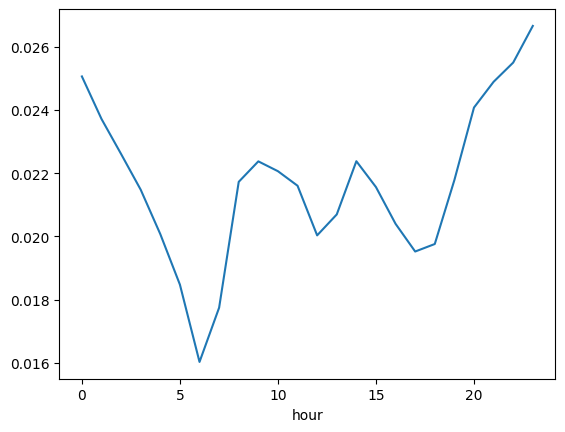

In [47]:
hourly_consumption = df.groupby('hour')['t_kWh'].mean()

hourly_consumption.plot()

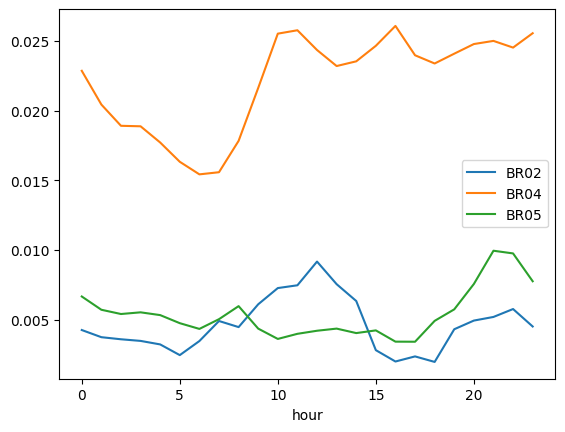

In [48]:
sample_meters = df['meter'].unique()[:3]

for m in sample_meters:
    temp = df[df['meter'] == m]
    hourly = temp.groupby('hour')['t_kWh'].mean()
    hourly.plot(label=m)

import matplotlib.pyplot as plt
plt.legend()
plt.show()

In [50]:
df = df.set_index('x_Timestamp')

In [51]:
df.index

DatetimeIndex(['2021-01-02 00:00:00', '2021-01-02 00:03:00',
               '2021-01-02 00:06:00', '2021-01-02 00:09:00',
               '2021-01-02 00:12:00', '2021-01-02 00:15:00',
               '2021-01-02 00:18:00', '2021-01-02 00:21:00',
               '2021-01-02 00:24:00', '2021-01-02 00:27:00',
               ...
               '2021-10-31 23:30:00', '2021-10-31 23:33:00',
               '2021-10-31 23:36:00', '2021-10-31 23:39:00',
               '2021-10-31 23:42:00', '2021-10-31 23:45:00',
               '2021-10-31 23:48:00', '2021-10-31 23:51:00',
               '2021-10-31 23:54:00', '2021-10-31 23:57:00'],
              dtype='datetime64[ns]', name='x_Timestamp', length=3300480, freq=None)

In [ ]:
df_resampled = df.groupby('meter').resample('1H').mean().reset_index() #Resampling to hourly data

In [ ]:
df_resampled.head() 
# Data reduced:
# From ~3.3M → 175K rows
#  Much more manageable
#  Time is now consistent:
# Exactly 1-hour intervals
# Per meter → uniform structure
#  Noise reduced:
# 3-min fluctuations smoothed
# Zero noise reduced naturally


,meter,x_Timestamp,t_kWh,z_Avg Voltage (Volt),z_Avg Current (Amp),y_Freq (Hz),hour,day,month,day_of_week
0,BR02,2021-01-02 00:00:00,0.00850,253.9020,0.7160,50.0535,0.0,2.0,1.0,5.0
1,BR02,2021-01-02 01:00:00,0.00105,255.0410,0.1425,50.0170,1.0,2.0,1.0,5.0
2,BR02,2021-01-02 02:00:00,0.00100,255.4345,0.1335,49.9955,2.0,2.0,1.0,5.0
3,BR02,2021-01-02 03:00:00,0.00100,255.7510,0.1320,50.0160,3.0,2.0,1.0,5.0
4,BR02,2021-01-02 04:00:00,0.00100,255.8580,0.1300,50.0285,4.0,2.0,1.0,5.0


In [54]:
df_resampled.shape

(175176, 10)

In [56]:
df_resampled['hour'] = df_resampled['x_Timestamp'].dt.hour
df_resampled['day'] = df_resampled['x_Timestamp'].dt.day
df_resampled['month'] = df_resampled['x_Timestamp'].dt.month
df_resampled['day_of_week'] = df_resampled['x_Timestamp'].dt.dayofweek

In [57]:
df_resampled.head()

,meter,x_Timestamp,t_kWh,z_Avg Voltage (Volt),z_Avg Current (Amp),y_Freq (Hz),hour,day,month,day_of_week
0,BR02,2021-01-02 00:00:00,0.00850,253.9020,0.7160,50.0535,0,2,1,5
1,BR02,2021-01-02 01:00:00,0.00105,255.0410,0.1425,50.0170,1,2,1,5
2,BR02,2021-01-02 02:00:00,0.00100,255.4345,0.1335,49.9955,2,2,1,5
3,BR02,2021-01-02 03:00:00,0.00100,255.7510,0.1320,50.0160,3,2,1,5
4,BR02,2021-01-02 04:00:00,0.00100,255.8580,0.1300,50.0285,4,2,1,5


In [58]:
df_resampled.isna().sum()

meter                       0
x_Timestamp                 0
t_kWh                   10152
z_Avg Voltage (Volt)    10152
z_Avg Current (Amp)     10152
y_Freq (Hz)             10152
hour                        0
day                         0
month                       0
day_of_week                 0
dtype: int64

In [59]:
(df_resampled == 0).sum()

meter                       0
x_Timestamp                 0
t_kWh                    5874
z_Avg Voltage (Volt)     3799
z_Avg Current (Amp)      5478
y_Freq (Hz)              3799
hour                     7299
day                         0
month                       0
day_of_week             24840
dtype: int64

In [60]:
df_resampled = df_resampled.sort_values(['meter', 'x_Timestamp'])

In [64]:
cols = ['t_kWh', 'z_Avg Voltage (Volt)', 'z_Avg Current (Amp)', 'y_Freq (Hz)']

def interpolate_group(group):
    group = group.set_index('x_Timestamp')
    group[cols] = group[cols].interpolate(method='time', limit=2)
    return group.reset_index()

df_resampled = df_resampled.groupby('meter', group_keys=False).apply(interpolate_group)

In [65]:
df_resampled.isna().sum()

x_Timestamp                0
meter                      0
t_kWh                   9740
z_Avg Voltage (Volt)    9740
z_Avg Current (Amp)     9740
y_Freq (Hz)             9740
hour                       0
day                        0
month                      0
day_of_week                0
dtype: int64

In [66]:
before = df_resampled.shape[0]

after = df_resampled.dropna().shape[0]

print("Before:", before)
print("After:", after)
print("Dropped:", before - after)

Before: 175176
After: 165436
Dropped: 9740


In [67]:
df_resampled.isna().sum()

x_Timestamp                0
meter                      0
t_kWh                   9740
z_Avg Voltage (Volt)    9740
z_Avg Current (Amp)     9740
y_Freq (Hz)             9740
hour                       0
day                        0
month                      0
day_of_week                0
dtype: int64

In [68]:
df_resampled = df_resampled.dropna()

In [69]:
df_resampled.isna().sum()

x_Timestamp             0
meter                   0
t_kWh                   0
z_Avg Voltage (Volt)    0
z_Avg Current (Amp)     0
y_Freq (Hz)             0
hour                    0
day                     0
month                   0
day_of_week             0
dtype: int64

In [71]:
df_resampled.shape

(165436, 10)

In [72]:
df_sim = df_resampled.copy()

In [74]:
df_sim.info()

<class 'pandas.core.frame.DataFrame'>
Index: 165436 entries, 0 to 7295
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   x_Timestamp           165436 non-null  datetime64[ns]
 1   meter                 165436 non-null  object        
 2   t_kWh                 165436 non-null  float64       
 3   z_Avg Voltage (Volt)  165436 non-null  float64       
 4   z_Avg Current (Amp)   165436 non-null  float64       
 5   y_Freq (Hz)           165436 non-null  float64       
 6   hour                  165436 non-null  int32         
 7   day                   165436 non-null  int32         
 8   month                 165436 non-null  int32         
 9   day_of_week           165436 non-null  int32         
dtypes: datetime64[ns](1), float64(4), int32(4), object(1)
memory usage: 11.4+ MB
